# Single Participant Analysis - P004

**Time-Delay Embedding Analysis of Locomotor Resilience**

This notebook demonstrates the complete TDE pipeline for analyzing postural resilience during perturbed gait.

**Author:** Victor SALVAT  
**Date:** 2026-03-31  
**Participant:** 004 (Young adult)

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from scipy.signal import find_peaks, savgol_filter

sys.path.append('../sources/python')

from load_data import load_pmocap_file
from preprocessing import preprocess_pipeline
from time_delay_embedding import compute_ami, compute_fnn, phase_space_reconstruction
from state_space import create_reference_trajectory, compute_euclidean_distances, compute_torus_thresholds
from perturbation_detection import detect_beeps, detect_perturbations
from resilience_metrics import compute_all_perturbation_metrics
from visualization import generate_all_figures

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("✓ Setup complete")

✓ Setup complete


In [20]:
data = load_pmocap_file('../data/antoine/004_Cued.mat')
print("\n✓ Data loaded")

Loading pMOCAP file: 004_Cued.mat
    Sacrum markers: 4 × 192000 samples
    Occluded samples: 23350 (3.04%)
    Analog signal: 240065 samples at 500.0 Hz
  ✓ Loaded successfully
    Participant: 004
    Duration: 480.00 s
    Sacrum fs: 400.0 Hz
    Analog fs: 500.0 Hz

✓ Data loaded


In [21]:
preprocessed = preprocess_pipeline(
    data['sacrum'],
    apply_emd=True,
    downsample_factor=4
)

sacrum_z = preprocessed['sacrum_z']
time_signal = preprocessed['time']
fs = 100

print(f"\n✓ Signal: {len(sacrum_z)} samples at {fs} Hz")


PREPROCESSING PIPELINE

[1/5] Computing barycenter...
  Barycenter computed: (192000, 3)
    X range: [-1283.16, 1197.02] mm
    Y range: [-3341.05, 3243.84] mm
    Z range: [-50.68, 48.79] mm

[2/5] EMD decomposition...
  Applying EMD decomposition...
    Decomposed into 14 IMFs
    Combined IMFs [3, 4, 5, 6, 7, 8]
    Reconstructed signal: mean=0.58, std=16.43

[3/5] Butterworth filtering...
  Butterworth filter applied: 4th order, fc=5.0 Hz

[4/5] Downsampling...
  Downsampled by factor 4: 192000 → 48000 samples

[5/5] Creating time vector...

PREPROCESSING COMPLETE
  Original: 192000 samples @ 400.0 Hz
  Final: 48000 samples @ 100.0 Hz
  Duration: 479.99 seconds


✓ Signal: 48000 samples at 100 Hz


In [22]:
tau_optimal, ami_values = compute_ami(sacrum_z, max_lag=100)
dim_optimal, fnn_rates = compute_fnn(sacrum_z, max_dim=10, tau=tau_optimal)

print(f"\n✓ TDE parameters: τ={tau_optimal}, dim={dim_optimal}")


✓ TDE parameters: τ=19, dim=4


In [23]:
state_space = phase_space_reconstruction(sacrum_z, tau_optimal, dim=3)
print(f"\n✓ State-space: {state_space.shape}")


✓ State-space: (47962, 3)


In [24]:
beep_times, _ = detect_beeps(data['analog']['value'], fs=data['analog']['fs'])
perturbations = detect_perturbations(beep_times)

print(f"\n✓ Perturbations:")
print(f"  Slow: {perturbations['slow_time']:.2f}s")
print(f"  Fast: {perturbations['fast_time']:.2f}s")

  Detected 895 beeps
    First beep: 0.50 s
    Last beep: 479.86 s

  Baseline cadence: 111.9 bpm
  Baseline interval: 0.536 s
  Detection bounds: [0.456, 0.617] s

  Perturbations detected:
    Slow: t = 173.54 s (beep #323)
    Fast: t = 354.61 s (beep #659)

✓ Perturbations:
  Slow: 173.54s
  Fast: 354.61s


In [25]:
if not np.isnan(perturbations['slow_time']) and not np.isnan(perturbations['fast_time']):
    baseline_end_time = min(perturbations['slow_time'], perturbations['fast_time']) - 10
elif not np.isnan(perturbations['slow_time']):
    baseline_end_time = perturbations['slow_time'] - 10
elif not np.isnan(perturbations['fast_time']):
    baseline_end_time = perturbations['fast_time'] - 10
else:
    baseline_end_time = 60

baseline_end_idx = int(baseline_end_time * fs)
reference = create_reference_trajectory(state_space, baseline_end_idx)

distances = compute_euclidean_distances(state_space, reference, phase_matching=False)

print(f"\n✓ Distances computed")
print(f"  Mean: {np.mean(distances):.2f} mm")
print(f"  Max: {np.max(distances):.2f} mm")

  Reference trajectory created from baseline:
    Baseline points: 16354
    Centroid: [0.60, 0.59, 0.59]
    Smoothing window: 50

✓ Distances computed
  Mean: 12.30 mm
  Max: 37.15 mm


In [26]:
baseline_mask = np.arange(len(distances)) < baseline_end_idx
thresholds = compute_torus_thresholds(distances, baseline_mask)

print(f"\n✓ Thresholds: T1={thresholds['T1']:.2f}, T2={thresholds['T2']:.2f}, T3={thresholds['T3']:.2f} mm")


  Torus thresholds computed:
    T1 (1σ): 21.93 mm - Very stable: 79.5%
    T2 (2σ): 30.93 mm - Stable: 19.9%
    T3 (3σ): 39.94 mm - Unstable: 0.7%
    >T3:     Very unstable: 0.0%

✓ Thresholds: T1=21.93, T2=30.93, T3=39.94 mm


In [27]:
steps, _ = find_peaks(-sacrum_z)
print(f"\n✓ Detected {len(steps)} steps")


✓ Detected 850 steps


In [28]:
metrics = compute_all_perturbation_metrics(
    distances=distances,
    thresholds=thresholds,
    perturbations=perturbations,
    step_indices=steps,
    fs=fs
)

print("\n" + "="*60)
print("RESILIENCE METRICS - P004")
print("="*60)
for name in ['slow', 'fast']:
    if name in metrics:
        m = metrics[name]
        print(f"\n{name.upper()}:")
        print(f"  Peak: {m['peak_value']:.2f} mm")
        print(f"  Recovery: {m['recovery_time']:.2f} s")
print("="*60)


COMPUTING RESILIENCE METRICS

[SLOW] Perturbation at t=173.54s
  Peak deviation: 26.42 mm at t=174.52s
  Recovery time: 0.00 s
  Steps to recovery: 0

[FAST] Perturbation at t=354.61s
  Peak deviation: 37.15 mm at t=356.83s
  Recovery time: 1.22 s
  Steps to recovery: 3



RESILIENCE METRICS - P004

SLOW:
  Peak: 26.42 mm
  Recovery: 0.00 s

FAST:
  Peak: 37.15 mm
  Recovery: 1.22 s


In [29]:
time_distances = np.arange(len(distances)) / fs

figures = generate_all_figures(
    tau=tau_optimal,
    dim=dim_optimal,
    ami_values=ami_values,
    fnn_rates=fnn_rates,
    time=time_distances,
    state_space=state_space,
    distances=distances,
    reference=reference,
    thresholds=thresholds,
    perturbations=perturbations,
    metrics=metrics,
    participant_id='004',
    output_dir='../results/figures'
)

print("\n✓ Figures generated")


Generating figures for participant 004...
  Saved: ..\results\figures\004_tde_parameters.png
  Saved: ..\results\figures\004_state_space_3d.png
  Saved: ..\results\figures\004_recovery_curves.png
✓ Generated 3 figures

✓ Figures generated



GENERATING IMPROVED RECOVERY CURVES
✓ Saved: ..\results\figures\004_recovery_curves.png


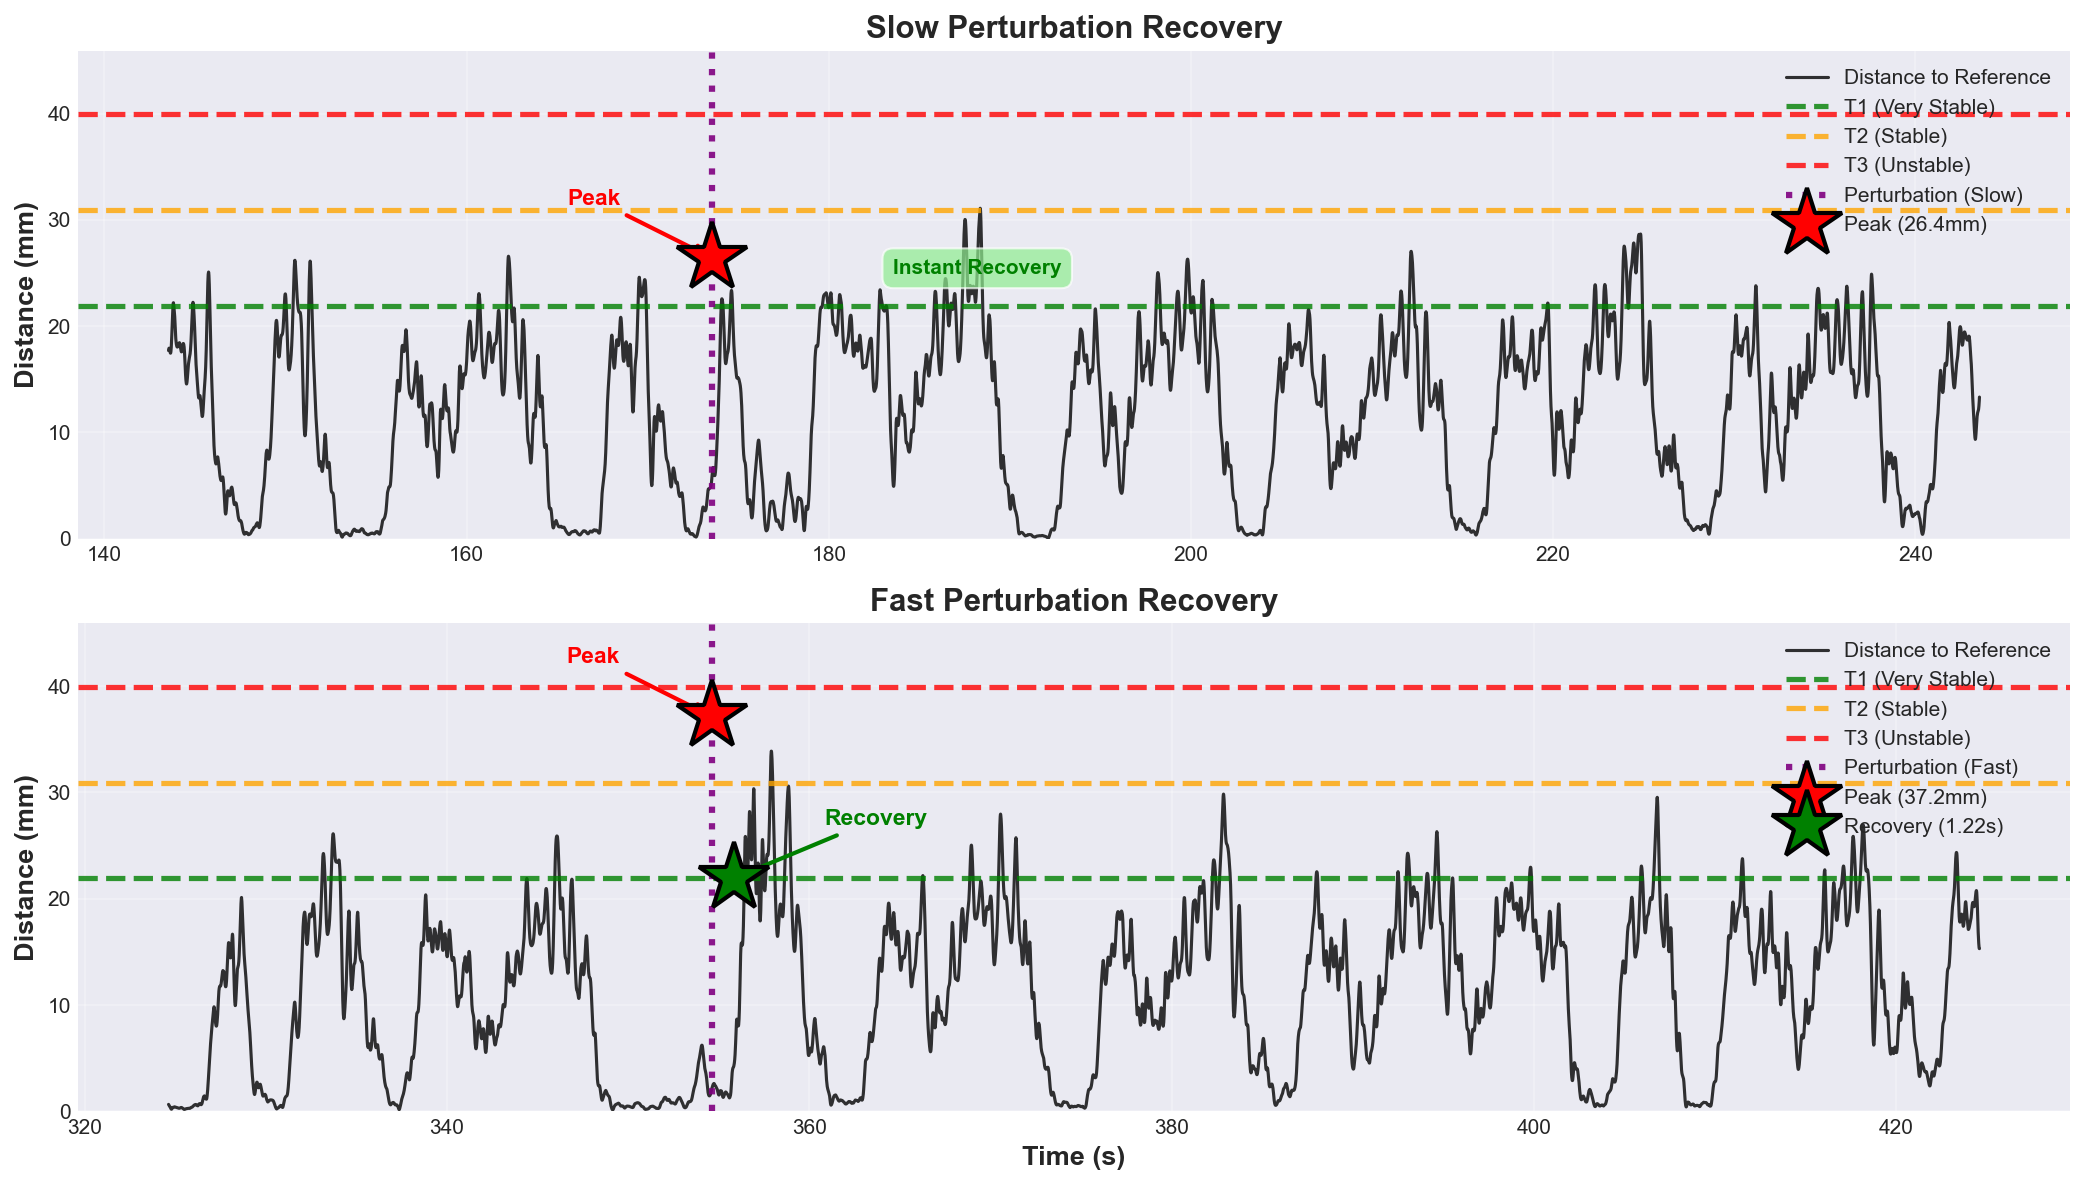

In [30]:
print("\n" + "="*70)
print("GENERATING IMPROVED RECOVERY CURVES")
print("="*70)

window_length = 51
polyorder = 3
distances_smooth = savgol_filter(distances, window_length, polyorder)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for idx, (name, ax) in enumerate(zip(['slow', 'fast'], axes)):
    if name not in metrics:
        continue
    
    m = metrics[name]
    pert_time = perturbations[f'{name}_time']
    
    window_start = max(0, pert_time - 30)
    window_end = min(time_distances[-1], pert_time + 70)
    
    mask = (time_distances >= window_start) & (time_distances <= window_end)
    t_window = time_distances[mask]
    d_window = distances_smooth[mask]
    
    ax.plot(t_window, d_window, 'k-', linewidth=1.5, alpha=0.8, label='Distance to Reference')
    
    ax.axhline(thresholds['T1'], color='green', linestyle='--', linewidth=2.5, 
               alpha=0.8, label='T1 (Very Stable)')
    ax.axhline(thresholds['T2'], color='orange', linestyle='--', linewidth=2.5,
               alpha=0.8, label='T2 (Stable)')
    ax.axhline(thresholds['T3'], color='red', linestyle='--', linewidth=2.5,
               alpha=0.8, label='T3 (Unstable)')
    
    ax.axvline(pert_time, color='purple', linestyle=':', linewidth=3, 
               alpha=0.9, label=f'Perturbation ({name.capitalize()})')
    
    peak_time = m.get('peak_time', pert_time)
    peak_value = m['peak_value']
    ax.plot(peak_time, peak_value, 'r*', markersize=35, markeredgecolor='black',
            markeredgewidth=2, label=f'Peak ({peak_value:.1f}mm)', zorder=10)
    
    ax.annotate('Peak', xy=(peak_time, peak_value),
               xytext=(peak_time-8, peak_value+5),
               fontsize=11, fontweight='bold', color='red',
               arrowprops=dict(arrowstyle='->', color='red', lw=2))
    
    if m['recovery_time'] > 0:
        recovery_time = peak_time + m['recovery_time']
        ax.plot(recovery_time, thresholds['T1'], 'g*', markersize=35, 
                markeredgecolor='black', markeredgewidth=2,
                label=f"Recovery ({m['recovery_time']:.2f}s)", zorder=10)
        
        ax.annotate('Recovery', xy=(recovery_time, thresholds['T1']),
                   xytext=(recovery_time+5, thresholds['T1']+5),
                   fontsize=11, fontweight='bold', color='green',
                   arrowprops=dict(arrowstyle='->', color='green', lw=2))
    else:
        ax.text(peak_time + 10, thresholds['T1'] + 3, 'Instant Recovery',
                fontsize=10, fontweight='bold', color='green',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.7))
    
    if idx == 0:
        ax.set_title('Slow Perturbation Recovery', fontweight='bold', fontsize=15)
    else:
        ax.set_title('Fast Perturbation Recovery', fontweight='bold', fontsize=15)
        ax.set_xlabel('Time (s)', fontweight='bold', fontsize=13)
    
    ax.set_ylabel('Distance (mm)', fontweight='bold', fontsize=13)
    ax.legend(loc='upper right', fontsize=10, framealpha=0.95)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, max(d_window.max(), thresholds['T3']) * 1.15])

plt.tight_layout()
output_path = Path('../results/figures/004_recovery_curves.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {output_path}")
plt.show()

In [32]:
print("\n" + "="*70)
print("EXPORTING PHASE SPACE DATA FOR 3D VISUALIZATION")
print("="*70)

def export_phase_space_window(state_space, distances, time, thresholds, 
                                reference_dict, pert_time, window_seconds=60, 
                                output_path='phase_space.csv'):
    """Export phase space window with reference trajectory."""
    fs = 100
    pert_idx = int(pert_time * fs)
    window_frames = int(window_seconds * fs)
    
    start_idx = max(0, pert_idx - window_frames // 2)
    end_idx = min(len(state_space), pert_idx + window_frames // 2)
    
    X = state_space[start_idx:end_idx, 0]
    Y = state_space[start_idx:end_idx, 1]
    Z = state_space[start_idx:end_idx, 2]
    
    dist_window = distances[start_idx:end_idx]
    time_window = time[start_idx:end_idx]
    
    reference_traj = reference_dict['trajectory']
    
    ref_indices = np.linspace(0, len(reference_traj)-1, len(X)).astype(int)
    X_ref = reference_traj[ref_indices, 0]
    Y_ref = reference_traj[ref_indices, 1]
    Z_ref = reference_traj[ref_indices, 2]
    
    stability = []
    for d in dist_window:
        if d <= thresholds['T1']:
            stability.append('T1')
        elif d <= thresholds['T2']:
            stability.append('T2')
        elif d <= thresholds['T3']:
            stability.append('T3')
        else:
            stability.append('Unstable')
    
    df = pd.DataFrame({
        'X': X,
        'Y': Y,
        'Z': Z,
        'Time': time_window,
        'Distance': dist_window,
        'Stability': stability,
        'X_ref': X_ref,
        'Y_ref': Y_ref,
        'Z_ref': Z_ref
    })
    
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(output_path, index=False)
    print(f"  ✓ Saved: {output_path} ({len(df)} points)")
    
    thresholds_path = output_path.parent / f"{output_path.stem}_thresholds.csv"
    pd.DataFrame([
        {'Threshold': 'T1', 'Value': thresholds['T1']},
        {'Threshold': 'T2', 'Value': thresholds['T2']},
        {'Threshold': 'T3', 'Value': thresholds['T3']}
    ]).to_csv(thresholds_path, index=False)
    print(f"  ✓ Saved: {thresholds_path}")

if not np.isnan(perturbations['slow_time']):
    export_phase_space_window(
        state_space, distances, time_distances, thresholds, reference,
        perturbations['slow_time'],
        window_seconds=60,
        output_path='../results/figures/phase_space_SLOW.csv'
    )

if not np.isnan(perturbations['fast_time']):
    export_phase_space_window(
        state_space, distances, time_distances, thresholds, reference,
        perturbations['fast_time'],
        window_seconds=60,
        output_path='../results/figures/phase_space_FAST.csv'
    )

print("="*70)


EXPORTING PHASE SPACE DATA FOR 3D VISUALIZATION
  ✓ Saved: ..\results\figures\phase_space_SLOW.csv (6000 points)
  ✓ Saved: ..\results\figures\phase_space_SLOW_thresholds.csv
  ✓ Saved: ..\results\figures\phase_space_FAST.csv (6000 points)
  ✓ Saved: ..\results\figures\phase_space_FAST_thresholds.csv


In [33]:
summary = {
    'Participant': '004',
    'Group': 'Young',
    'Slow_Peak': metrics.get('slow', {}).get('peak_value', np.nan),
    'Slow_Recovery': metrics.get('slow', {}).get('recovery_time', np.nan),
    'Fast_Peak': metrics.get('fast', {}).get('peak_value', np.nan),
    'Fast_Recovery': metrics.get('fast', {}).get('recovery_time', np.nan),
}

df = pd.DataFrame([summary])
output_path = Path('../results/metrics/004_metrics.csv')
output_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_path, index=False)

print(f"\n✓ Metrics saved: {output_path}")
print(df.to_string(index=False))


✓ Metrics saved: ..\results\metrics\004_metrics.csv
Participant Group  Slow_Peak  Slow_Recovery  Fast_Peak  Fast_Recovery
        004 Young  26.424571            0.0  37.150039           1.22
